In [2]:
import numpy as np
import pandas as pd 
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.utils.data as tdata
from sklearn.preprocessing import StandardScaler
from datetime import date, datetime, timedelta 
from dateutil import relativedelta
from timeit import default_timer as timer

import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings("ignore")

from preprocess_data import * 
from model_training import *
from test_models import *

In [3]:
import sys
import os 
pjrt = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(pjrt)

from src.load_data import load_stocks
from src.xgboost_model.xgboost_etl import *

In [4]:
# start with a basic model
start_date = "2015-11-01"
end_date = datetime.today().strftime("%Y-%m-%d")
cutoff = datetime(2025, 9, 1, 0, 0, 0)

df = load_stocks(["AAPL"], start_date, end_date, use_polars=False)
# df_full = prep_columns(df, "close").to_pandas().dropna()

feat_cols = [c for c in df.columns if c not in ["date", "ticker", "close"]]

# df_full.head()
df.head()

[*********************100%***********************]  1 of 1 completed


Field,date,ticker,close,high,low,open,volume
0,2015-11-02,AAPL,27.205872,27.246283,26.853394,27.120559,128813200
1,2015-11-03,AAPL,27.517935,27.724482,27.098104,27.118311,182076000
2,2015-11-04,AAPL,27.389971,27.798575,27.304658,27.643664,179544400
3,2015-11-05,AAPL,27.263704,27.662785,27.096858,27.473390,158210800
4,2015-11-06,AAPL,27.295267,27.464369,27.196062,27.306541,132169200


In [4]:
# for some feature engineering, these guys (https://arxiv.org/html/2501.17366v1#S3) used:
# 3.1 Data Sources and Features

# The dataset used in this study encompasses daily values for the S&P 500 (SPX) over the period of October 2013 to September 2024. The historical SPX data include:

# • 50 and 200-day Moving Averages (MOV_AVG_50/200D)
# • 14-day Relative Strength Index (RSI_14D)
# • Open and Closing Prices (PX_OPEN/CLOSE)
# • High and Low Prices (PX_HIGH/LOW)
# • Daily Price High-Low Difference (PX_HIGH_LOW_DIFFERENCE)
# • Daily Volume (PX_VOLUME)
# • 30-day Volatility (VOLATILITY_30D)
# • Beta (BETA_ADJ_OVERRIDABLE)

In [5]:
# even worth doing lstm
lookback = 14
train_prop = 0.7

values = df[feat_cols + ["close"]].values.astype("float32")

X_list, y_list = [], []
for i in range(lookback, len(values)):
    X_list.append(values[i-lookback:i, :-1])
    y_list.append(values[i, -1])

y_all = np.array(y_list)
n_train = int(len(y_all) * train_prop)

y_train_np = y_all[:n_train]
y_test_np = y_all[n_train:]

y_pred_naive = np.roll(y_all, 1)[n_train:]
y_true = y_test_np
naive_rmse = np.sqrt(np.mean((y_pred_naive - y_true) ** 2))
print(f"naive 1-step RMSE (y_t = y_(t-1)): {naive_rmse:.5f}")

naive 1-step RMSE (y_t = y_(t-1)): 3.25285


In [18]:
X_train, X_test, y_train, y_test, scaler = split_scale_make_sequences(
    df, feat_cols, "close", lookback=14, use_delta=False
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1764, 14, 4]) torch.Size([1764]) torch.float32 torch.float32
torch.Size([762, 14, 4]) torch.Size([762]) torch.float32 torch.float32


# experiment 1

models trained with base hyperparameters
- 1 layer
- 0.0 dropout
- 14 day lookback window for sequences
- 1e-3 LR, 1e-3 weight decay
- 50 epochs

In [19]:
input_size = X_train.shape[-1]

model1 = LSTMStockForecaster(input_units=input_size)
model2 = LSTMDeepStackStockForecaster(input_units=input_size)
model3 = LSTMBiDirStockForecaster(input_units=input_size)
model4 = AttentiveLSTMStockForecaster(input_units=input_size)
model5 = GRUStockForecaster(input_units=input_size)

In [20]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 50

In [21]:
res1 = train_model(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 64.36334
 test_loss: 126.17053
 run time: 0.32119591697119176


epoch: 1
 train loss: 11.88386
 test_loss: 36.39019
 run time: 0.2858620000188239


epoch: 2
 train loss: 3.56044
 test_loss: 29.83259
 run time: 0.299201833026018


epoch: 3
 train loss: 2.98532
 test_loss: 26.41843
 run time: 0.2767749589984305


epoch: 4
 train loss: 2.74663
 test_loss: 24.63673
 run time: 0.2820390419801697


epoch: 5
 train loss: 2.44385
 test_loss: 22.06643
 run time: 0.2825630000443198


epoch: 6
 train loss: 2.56758
 test_loss: 21.28521
 run time: 0.2788621669751592


epoch: 7
 train loss: 2.29090
 test_loss: 20.06782
 run time: 0.2773272499907762


epoch: 8
 train loss: 2.25351
 test_loss: 18.20848
 run time: 0.27734595898073167


epoch: 9
 train loss: 2.34925
 test_loss: 17.67178
 run time: 0.2784019579994492


epoch: 10
 train loss: 2.15290
 test_loss: 18.11478
 run time: 0.275734290946275


epoch: 11
 train loss: 2.20482
 test_loss: 16.38939
 run time: 0.27513700001873076


In [22]:
res2 = train_model(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.43928
 test_loss: 179.84685
 run time: 0.49811012495774776


epoch: 1
 train loss: 65.46413
 test_loss: 165.80800
 run time: 0.49930270900949836


epoch: 2
 train loss: 57.19478
 test_loss: 153.00352
 run time: 0.47678787499899045


epoch: 3
 train loss: 49.51610
 test_loss: 140.42433
 run time: 0.4824573749792762


epoch: 4
 train loss: 42.12238
 test_loss: 127.92751
 run time: 0.46403920894954354


epoch: 5
 train loss: 35.22589
 test_loss: 115.65408
 run time: 0.4582978749531321


epoch: 6
 train loss: 28.61232
 test_loss: 103.48481
 run time: 0.4523371660034172


epoch: 7
 train loss: 22.41606
 test_loss: 91.54494
 run time: 0.45537183299893513


epoch: 8
 train loss: 16.84789
 test_loss: 79.96867
 run time: 0.4654192499583587


epoch: 9
 train loss: 12.12824
 test_loss: 70.27923
 run time: 0.4571638330235146


epoch: 10
 train loss: 8.96954
 test_loss: 62.40819
 run time: 0.46176949999062344


epoch: 11
 train loss: 6.65540
 test_loss: 55.85440
 run time: 

In [23]:
res3 = train_model(
    model=model3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 77.20331
 test_loss: 167.02208
 run time: 0.5078948750160635


epoch: 1
 train loss: 55.19954
 test_loss: 136.77364
 run time: 0.4851145420107059


epoch: 2
 train loss: 38.07893
 test_loss: 111.96066
 run time: 0.4853407500195317


epoch: 3
 train loss: 24.36865
 test_loss: 89.44811
 run time: 0.49624875001609325


epoch: 4
 train loss: 14.17514
 test_loss: 71.04226
 run time: 0.4904592499951832


epoch: 5
 train loss: 8.46551
 test_loss: 63.20960
 run time: 0.5078333750134334


epoch: 6
 train loss: 5.50637
 test_loss: 50.34848
 run time: 0.5953989160479978


epoch: 7
 train loss: 4.09063
 test_loss: 45.21917
 run time: 0.5555912080453709


epoch: 8
 train loss: 3.27256
 test_loss: 41.53083
 run time: 0.564901958045084


epoch: 9
 train loss: 2.91029
 test_loss: 38.44400
 run time: 0.5016692090430297


epoch: 10
 train loss: 2.60243
 test_loss: 36.32043
 run time: 0.5130166659946553


epoch: 11
 train loss: 2.61766
 test_loss: 35.50201
 run time: 0.5589481250499

In [24]:
res4 = train_model(
    model=model4,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.61053
 test_loss: 179.64992
 run time: 0.46564483403926715


epoch: 1
 train loss: 65.58250
 test_loss: 165.44716
 run time: 0.3398918330203742


epoch: 2
 train loss: 56.80391
 test_loss: 153.02673
 run time: 0.33055524999508634


epoch: 3
 train loss: 49.17430
 test_loss: 140.23499
 run time: 0.3380854589631781


epoch: 4
 train loss: 41.90402
 test_loss: 127.59598
 run time: 0.33385987498331815


epoch: 5
 train loss: 35.12643
 test_loss: 115.30529
 run time: 0.32323116704355925


epoch: 6
 train loss: 28.37326
 test_loss: 103.05761
 run time: 0.32192091597244143


epoch: 7
 train loss: 22.13095
 test_loss: 91.17550
 run time: 0.31940387503709644


epoch: 8
 train loss: 16.49391
 test_loss: 80.22355
 run time: 0.3186487499624491


epoch: 9
 train loss: 12.62023
 test_loss: 70.86626
 run time: 0.3228260829928331


epoch: 10
 train loss: 9.65759
 test_loss: 63.52502
 run time: 0.37671316700289026


epoch: 11
 train loss: 7.68575
 test_loss: 57.70053
 run time:

In [25]:
res5 = train_model(
    model=model5,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model5.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.49940
 test_loss: 180.18498
 run time: 0.2886851669754833


epoch: 1
 train loss: 66.46494
 test_loss: 166.03387
 run time: 0.26193541701650247


epoch: 2
 train loss: 57.86564
 test_loss: 154.21083
 run time: 0.26982154202414677


epoch: 3
 train loss: 50.51407
 test_loss: 141.59464
 run time: 0.2589624589891173


epoch: 4
 train loss: 42.48011
 test_loss: 129.00374
 run time: 0.25706900004297495


epoch: 5
 train loss: 35.46394
 test_loss: 116.52898
 run time: 0.25703166698804125


epoch: 6
 train loss: 29.36947
 test_loss: 104.19332
 run time: 0.25976145797176287


epoch: 7
 train loss: 22.55729
 test_loss: 92.14150
 run time: 0.2568112500011921


epoch: 8
 train loss: 17.06197
 test_loss: 80.88609
 run time: 0.25546295795356855


epoch: 9
 train loss: 12.65209
 test_loss: 71.23858
 run time: 0.29483929194975644


epoch: 10
 train loss: 9.46484
 test_loss: 63.14269
 run time: 0.25734966597519815


epoch: 11
 train loss: 6.70832
 test_loss: 56.63871
 run time

In [26]:
def make_df_from_res(res):
    return pd.DataFrame(
    {
        "epoch": list(range(len(res["train_loss"]))),
        "train_loss": [t.item() for t in res["train_loss"]],
        "test_loss": [t.item() for t in res["test_loss"]]
    }
)

In [27]:
df_res1 = make_df_from_res(res1)
df_res2 = make_df_from_res(res2)
df_res3 = make_df_from_res(res3)
df_res4 = make_df_from_res(res4)
df_res5 = make_df_from_res(res5)

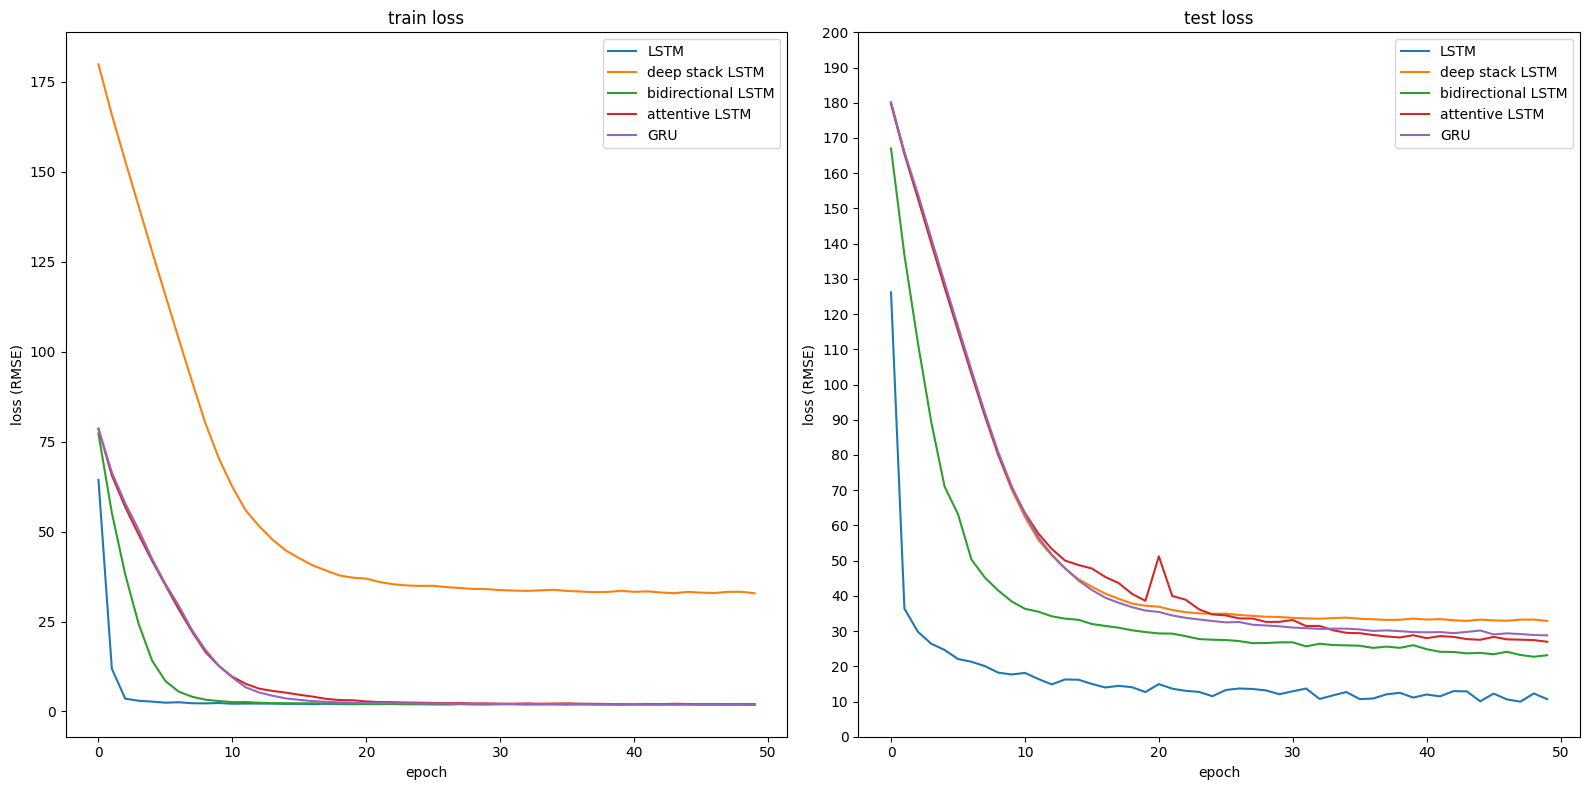

In [28]:
plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1["epoch"], df_res1["train_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["test_loss"], label="deep stack LSTM");
plt.plot(df_res3["epoch"], df_res3["train_loss"], label="bidirectional LSTM");
plt.plot(df_res4["epoch"], df_res4["train_loss"], label="attentive LSTM");
plt.plot(df_res5["epoch"], df_res5["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1["epoch"], df_res1["test_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["test_loss"], label="deep stack LSTM");
plt.plot(df_res3["epoch"], df_res3["test_loss"], label="bidirectional LSTM");
plt.plot(df_res4["epoch"], df_res4["test_loss"], label="attentive LSTM");
plt.plot(df_res5["epoch"], df_res5["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();

# experiment 1b
similar to experiment 1, but this time using the `delta` label option...

In [30]:
X_train, X_test, y_train, y_test, scaler = split_scale_make_sequences(
    df, feat_cols, "close", lookback=14, use_delta=True
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1763, 14, 4]) torch.Size([1763]) torch.float32 torch.float32
torch.Size([761, 14, 4]) torch.Size([761]) torch.float32 torch.float32


In [31]:
input_size = X_train.shape[-1]

model1 = LSTMStockForecaster(input_units=input_size)
model2 = LSTMDeepStackStockForecaster(input_units=input_size)
model3 = LSTMBiDirStockForecaster(input_units=input_size)
model4 = AttentiveLSTMStockForecaster(input_units=input_size)
model5 = GRUStockForecaster(input_units=input_size)

In [32]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 25

In [33]:
res1b = train_model(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.63024
 test_loss: 2.81749
 run time: 0.3162021660245955


epoch: 1
 train loss: 1.60634
 test_loss: 2.81807
 run time: 0.2745717079960741


epoch: 2
 train loss: 1.60206
 test_loss: 2.82002
 run time: 0.2746567499707453


epoch: 3
 train loss: 1.60451
 test_loss: 2.81825
 run time: 0.2739137079915963


epoch: 4
 train loss: 1.60220
 test_loss: 2.81860
 run time: 0.2785495410207659


epoch: 5
 train loss: 1.62153
 test_loss: 2.81849
 run time: 0.28227633296046406


epoch: 6
 train loss: 1.61210
 test_loss: 2.81896
 run time: 0.2813657500082627


epoch: 7
 train loss: 1.61588
 test_loss: 2.81869
 run time: 0.2762887499993667


epoch: 8
 train loss: 1.61407
 test_loss: 2.81844
 run time: 0.27477891702437773


epoch: 9
 train loss: 1.59406
 test_loss: 2.81871
 run time: 0.2952167500043288


epoch: 10
 train loss: 1.61686
 test_loss: 2.81801
 run time: 0.27453704096842557


epoch: 11
 train loss: 1.61914
 test_loss: 2.81934
 run time: 0.2728167499881238


epoch: 12
 

In [34]:
res2b = train_model(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.62115
 test_loss: 2.81921
 run time: 0.4649992500199005


epoch: 1
 train loss: 1.61348
 test_loss: 2.81978
 run time: 0.46078320901142433


epoch: 2
 train loss: 1.60749
 test_loss: 2.81791
 run time: 0.46079837501747534


epoch: 3
 train loss: 1.61770
 test_loss: 2.81834
 run time: 0.46066829201299697


epoch: 4
 train loss: 1.59878
 test_loss: 2.81865
 run time: 0.4819936670246534


epoch: 5
 train loss: 1.61059
 test_loss: 2.81950
 run time: 0.5098763330024667


epoch: 6
 train loss: 1.61696
 test_loss: 2.81824
 run time: 0.505678458022885


epoch: 7
 train loss: 1.61522
 test_loss: 2.81852
 run time: 0.5160034170257859


epoch: 8
 train loss: 1.62380
 test_loss: 2.81850
 run time: 0.509016124997288


epoch: 9
 train loss: 1.59269
 test_loss: 2.81876
 run time: 0.5186638329760171


epoch: 10
 train loss: 1.60914
 test_loss: 2.82008
 run time: 0.5111327500198968


epoch: 11
 train loss: 1.61349
 test_loss: 2.82002
 run time: 0.4936463750200346


epoch: 12
 tr

In [35]:
res3b = train_model(
    model=model3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.62470
 test_loss: 2.81652
 run time: 0.499963584006764


epoch: 1
 train loss: 1.63685
 test_loss: 2.81810
 run time: 0.49484866700368


epoch: 2
 train loss: 1.61106
 test_loss: 2.81963
 run time: 0.4953426249558106


epoch: 3
 train loss: 1.60860
 test_loss: 2.81601
 run time: 0.49716883298242465


epoch: 4
 train loss: 1.61455
 test_loss: 2.81738
 run time: 0.4881280420231633


epoch: 5
 train loss: 1.62856
 test_loss: 2.82213
 run time: 0.4874952499521896


epoch: 6
 train loss: 1.61723
 test_loss: 2.82097
 run time: 0.4886128749931231


epoch: 7
 train loss: 1.62060
 test_loss: 2.81932
 run time: 0.501323250005953


epoch: 8
 train loss: 1.61605
 test_loss: 2.82612
 run time: 0.5032856250181794


epoch: 9
 train loss: 1.59459
 test_loss: 2.82477
 run time: 0.5318987920181826


epoch: 10
 train loss: 1.59649
 test_loss: 2.82885
 run time: 0.5758034999598749


epoch: 11
 train loss: 1.62398
 test_loss: 2.82628
 run time: 0.5028344999882393


epoch: 12
 train 

In [36]:
res4b = train_model(
    model=model4,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.60344
 test_loss: 2.83652
 run time: 0.3304810000117868


epoch: 1
 train loss: 1.60250
 test_loss: 2.82107
 run time: 0.3181454999721609


epoch: 2
 train loss: 1.61486
 test_loss: 2.81830
 run time: 0.31891370797529817


epoch: 3
 train loss: 1.60731
 test_loss: 2.81871
 run time: 0.3177735829958692


epoch: 4
 train loss: 1.59279
 test_loss: 2.83326
 run time: 0.31737462495220825


epoch: 5
 train loss: 1.62346
 test_loss: 2.82025
 run time: 0.31701837497530505


epoch: 6
 train loss: 1.64010
 test_loss: 2.82213
 run time: 0.31819991598604247


epoch: 7
 train loss: 1.59366
 test_loss: 2.82009
 run time: 0.3188575839740224


epoch: 8
 train loss: 1.61098
 test_loss: 2.82322
 run time: 0.31787470798008144


epoch: 9
 train loss: 1.61999
 test_loss: 2.82147
 run time: 0.31780412496300414


epoch: 10
 train loss: 1.59287
 test_loss: 2.82216
 run time: 0.3174032079987228


epoch: 11
 train loss: 1.61230
 test_loss: 2.81994
 run time: 0.3342821670230478


epoch: 1

In [37]:
res5b = train_model(
    model=model5,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model5.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 1.62982
 test_loss: 2.81945
 run time: 0.26463133399374783


epoch: 1
 train loss: 1.60946
 test_loss: 2.81863
 run time: 0.26166133396327496


epoch: 2
 train loss: 1.62709
 test_loss: 2.81817
 run time: 0.26067104196408764


epoch: 3
 train loss: 1.62099
 test_loss: 2.81869
 run time: 0.2554394159815274


epoch: 4
 train loss: 1.61752
 test_loss: 2.82173
 run time: 0.2554594589746557


epoch: 5
 train loss: 1.62990
 test_loss: 2.82883
 run time: 0.25477670796681195


epoch: 6
 train loss: 1.62355
 test_loss: 2.82170
 run time: 0.25519354100106284


epoch: 7
 train loss: 1.61169
 test_loss: 2.81831
 run time: 0.25582712498726323


epoch: 8
 train loss: 1.59948
 test_loss: 2.81940
 run time: 0.2660615000058897


epoch: 9
 train loss: 1.61996
 test_loss: 2.81912
 run time: 0.2570126249920577


epoch: 10
 train loss: 1.61768
 test_loss: 2.81808
 run time: 0.26772787497611716


epoch: 11
 train loss: 1.61189
 test_loss: 2.81786
 run time: 0.2583875409909524


epoch: 

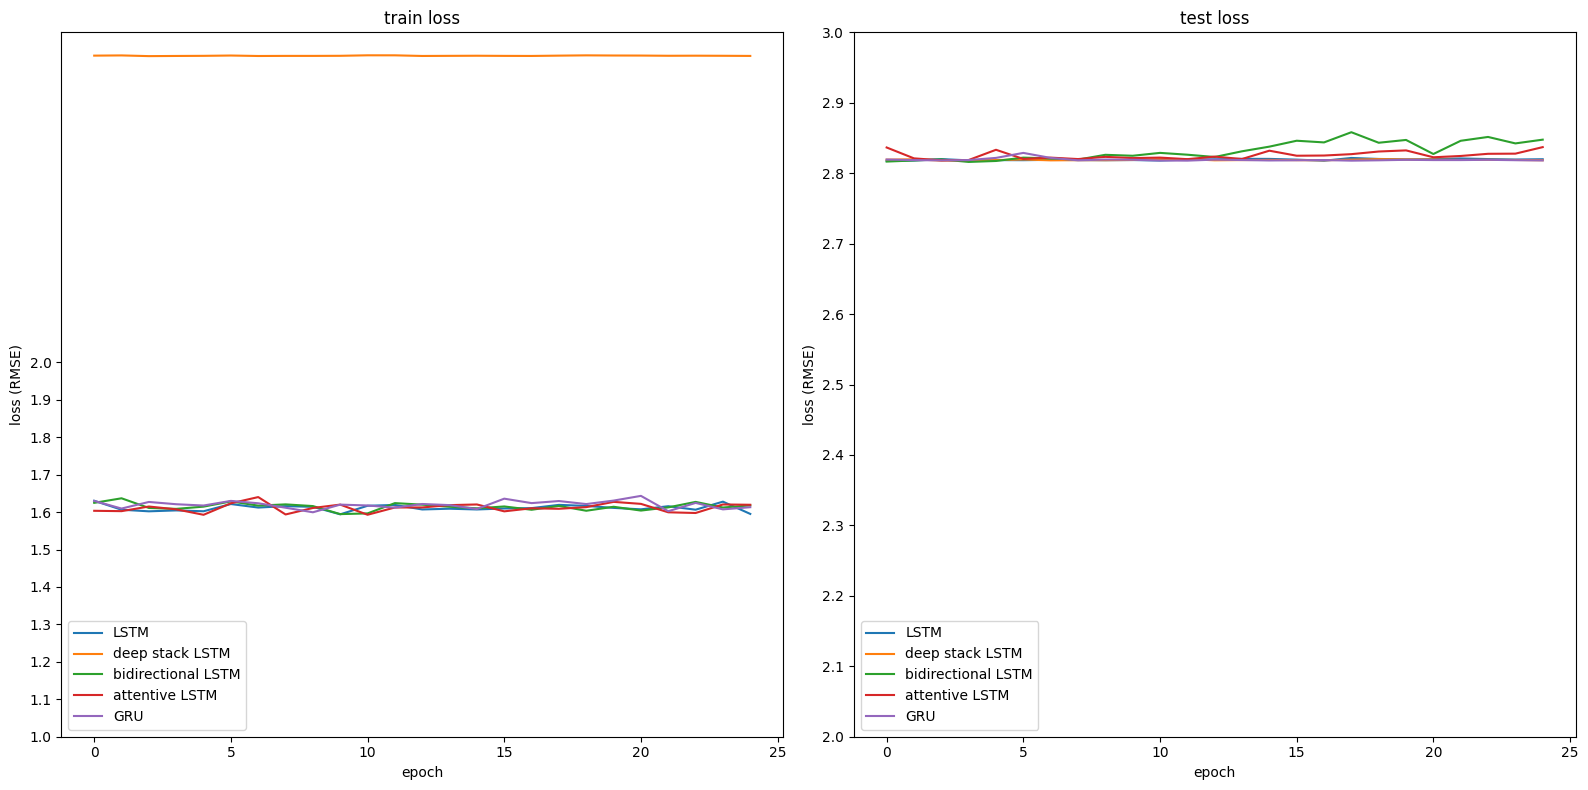

In [38]:
df_res1b = make_df_from_res(res1b)
df_res2b = make_df_from_res(res2b)
df_res3b = make_df_from_res(res3b)
df_res4b = make_df_from_res(res4b)
df_res5b = make_df_from_res(res5b)

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1b["epoch"], df_res1b["train_loss"], label="LSTM");
plt.plot(df_res2b["epoch"], df_res2b["test_loss"], label="deep stack LSTM");
plt.plot(df_res3b["epoch"], df_res3b["train_loss"], label="bidirectional LSTM");
plt.plot(df_res4b["epoch"], df_res4b["train_loss"], label="attentive LSTM");
plt.plot(df_res5b["epoch"], df_res5b["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(1.0, 2.1, 0.1));
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1b["epoch"], df_res1b["test_loss"], label="LSTM");
plt.plot(df_res2b["epoch"], df_res2b["test_loss"], label="deep stack LSTM");
plt.plot(df_res3b["epoch"], df_res3b["test_loss"], label="bidirectional LSTM");
plt.plot(df_res4b["epoch"], df_res4b["test_loss"], label="attentive LSTM");
plt.plot(df_res5b["epoch"], df_res5b["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(2.0, 3.1, 0.1));
plt.title("test loss");


plt.tight_layout();

# experiment 2
- updating `num_layers = 2` and `dropout = 0.3`

In [36]:
input_size = X_train.shape[-1]

model1v2 = LSTMStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model2v2 = LSTMBiDirStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model3v2 = AttentiveLSTMStockForecaster(input_units=input_size, num_layers=2, lstm_dropout=0.3)
model4v2 = GRUStockForecaster(input_units=input_size, num_layers=2, dropout=0.3)

In [37]:
res1v2 = train_model(
    model=model1v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 68.06859
 test_loss: 133.83585
 run time: 0.5829551249917131


epoch: 1
 train loss: 16.75265
 test_loss: 41.03820
 run time: 0.5332331669924315


epoch: 2
 train loss: 4.01510
 test_loss: 33.45517
 run time: 0.5433432910067495


epoch: 3
 train loss: 3.72563
 test_loss: 32.05269
 run time: 0.5512659169908147


epoch: 4
 train loss: 3.55503
 test_loss: 31.86129
 run time: 0.5582201670040376


epoch: 5
 train loss: 3.51905
 test_loss: 30.22644
 run time: 0.5258746670151595


epoch: 6
 train loss: 3.28614
 test_loss: 29.27867
 run time: 0.5257358750095591


epoch: 7
 train loss: 3.31590
 test_loss: 29.89479
 run time: 0.5285699579981156


epoch: 8
 train loss: 3.24957
 test_loss: 29.75231
 run time: 0.5350287920155097


epoch: 9
 train loss: 3.27787
 test_loss: 30.49650
 run time: 0.5218278329994064


epoch: 10
 train loss: 3.37528
 test_loss: 29.54161
 run time: 0.5203844579809811


epoch: 11
 train loss: 3.09995
 test_loss: 27.79624
 run time: 0.5209719580016099



In [38]:
res2v2 = train_model(
    model=model2v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 73.43818
 test_loss: 166.34349
 run time: 1.1308079170121346


epoch: 1
 train loss: 55.11823
 test_loss: 144.95692
 run time: 1.0184585000097286


epoch: 2
 train loss: 42.41323
 test_loss: 122.81301
 run time: 1.0441458749992307


epoch: 3
 train loss: 31.04139
 test_loss: 101.31363
 run time: 1.101381833985215


epoch: 4
 train loss: 19.69543
 test_loss: 81.11139
 run time: 1.0850076249917038


epoch: 5
 train loss: 11.69815
 test_loss: 64.79296
 run time: 1.1743863339943346


epoch: 6
 train loss: 7.29777
 test_loss: 54.89618
 run time: 1.0938357079867274


epoch: 7
 train loss: 5.28638
 test_loss: 48.09007
 run time: 1.0625143750221469


epoch: 8
 train loss: 4.18298
 test_loss: 43.76030
 run time: 0.9983756250003353


epoch: 9
 train loss: 3.62519
 test_loss: 40.39169
 run time: 0.9900169579777867


epoch: 10
 train loss: 3.45280
 test_loss: 38.37678
 run time: 1.1773895000224002


epoch: 11
 train loss: 3.16120
 test_loss: 37.28910
 run time: 1.136542916996

In [39]:
res3v2 = train_model(
    model=model3v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.56259
 test_loss: 179.03931
 run time: 0.6309261250135023


epoch: 1
 train loss: 66.52731
 test_loss: 165.15234
 run time: 0.5664540830184706


epoch: 2
 train loss: 57.96343
 test_loss: 152.53473
 run time: 0.558537749981042


epoch: 3
 train loss: 49.48162
 test_loss: 139.93372
 run time: 0.5596709999954328


epoch: 4
 train loss: 42.69123
 test_loss: 127.32158
 run time: 0.5594134159910027


epoch: 5
 train loss: 35.12530
 test_loss: 115.28000
 run time: 0.6024511250143405


epoch: 6
 train loss: 28.90018
 test_loss: 103.24181
 run time: 0.5944624580151867


epoch: 7
 train loss: 22.83001
 test_loss: 91.41109
 run time: 0.561655833007535


epoch: 8
 train loss: 17.22437
 test_loss: 79.92579
 run time: 0.5662200420047157


epoch: 9
 train loss: 12.63764
 test_loss: 70.44099
 run time: 0.5687813329859637


epoch: 10
 train loss: 9.43100
 test_loss: 62.31460
 run time: 0.5735499580041505


epoch: 11
 train loss: 6.78433
 test_loss: 55.92436
 run time: 0.570519

In [40]:
res4v2 = train_model(
    model=model4v2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4v2.parameters(), lr=1e-3, weight_decay=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.20359
 test_loss: 179.19598
 run time: 0.580916208011331


epoch: 1
 train loss: 66.58518
 test_loss: 165.43837
 run time: 0.4973740419954993


epoch: 2
 train loss: 57.71192
 test_loss: 153.53957
 run time: 0.5137881249829661


epoch: 3
 train loss: 50.07803
 test_loss: 140.86636
 run time: 0.5024007080064621


epoch: 4
 train loss: 43.21646
 test_loss: 128.36989
 run time: 0.505556375021115


epoch: 5
 train loss: 35.89096
 test_loss: 115.93118
 run time: 0.506846875010524


epoch: 6
 train loss: 29.39151
 test_loss: 103.71674
 run time: 0.5456507919880096


epoch: 7
 train loss: 23.02497
 test_loss: 91.59026
 run time: 0.5336168750072829


epoch: 8
 train loss: 17.13204
 test_loss: 80.38482
 run time: 0.5632191670010798


epoch: 9
 train loss: 12.58185
 test_loss: 70.89285
 run time: 0.5047794170095585


epoch: 10
 train loss: 9.20103
 test_loss: 62.49177
 run time: 0.5016721670108382


epoch: 11
 train loss: 6.65488
 test_loss: 56.04161
 run time: 0.6064621

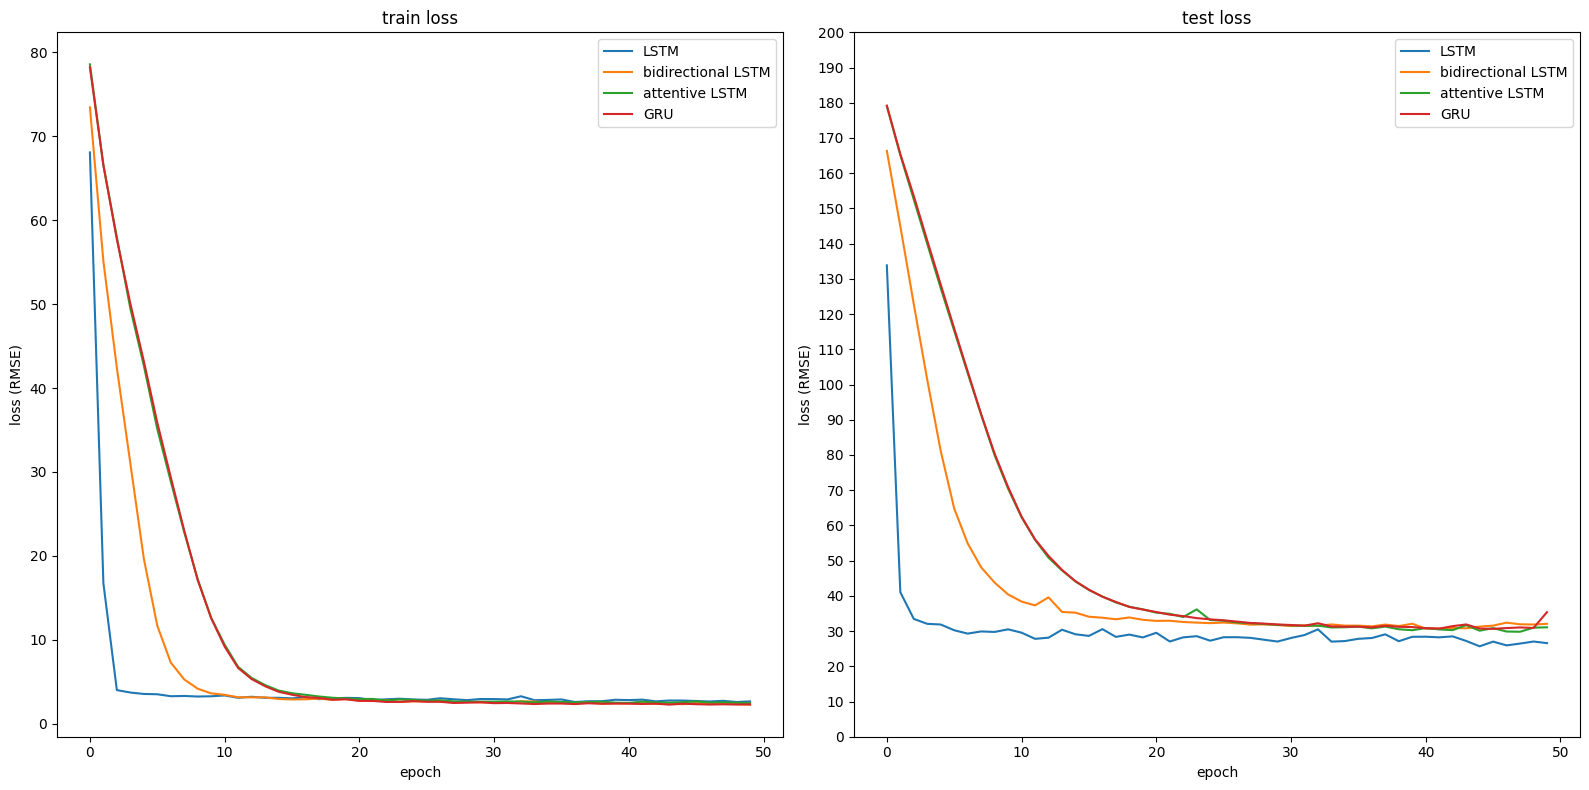

In [41]:
df_res1v2 = make_df_from_res(res1v2)
df_res2v2 = make_df_from_res(res2v2)
df_res3v2 = make_df_from_res(res3v2)
df_res4v2 = make_df_from_res(res4v2)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1v2["epoch"], df_res1v2["train_loss"], label="LSTM");
plt.plot(df_res2v2["epoch"], df_res2v2["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3v2["epoch"], df_res3v2["train_loss"], label="attentive LSTM");
plt.plot(df_res4v2["epoch"], df_res4v2["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1v2["epoch"], df_res1v2["test_loss"], label="LSTM");
plt.plot(df_res2v2["epoch"], df_res2v2["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3v2["epoch"], df_res3v2["test_loss"], label="attentive LSTM");
plt.plot(df_res4v2["epoch"], df_res4v2["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();

# experiment 3
same approach as experiment 1, but removing all features except timeseries  
i.e., _only_ model the autoregressive structure  

also increasing lookback from 14 to 30

In [27]:
X_train, X_test, y_train, y_test = process_single_feature_data(
    df=df, label="close", train_proportion=0.7, lookback=30
)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1743, 30, 1]) torch.Size([1743, 30, 1]) torch.float32 torch.float32
torch.Size([730, 30, 1]) torch.Size([730, 30, 1]) torch.float32 torch.float32


In [28]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 50

In [29]:
input_size = X_train.shape[-1]

model1v3 = LSTMStockForecaster(input_units=input_size)
model2v3 = LSTMBiDirStockForecaster(input_units=input_size)
model3v3 = AttentiveLSTMStockForecaster(input_units=input_size)
model4v3 = GRUStockForecaster(input_units=input_size)

In [30]:
res1v3 = train_model(
    model=model1v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 66.41460
 test_loss: 131.75105
 run time: 0.5997062920068856


epoch: 1
 train loss: 47.86356
 test_loss: 127.68386
 run time: 0.5037462500040419


epoch: 2
 train loss: 47.95971
 test_loss: 123.79359
 run time: 0.5021482500014827


epoch: 3
 train loss: 47.68727
 test_loss: 120.34516
 run time: 0.5324486249883194


epoch: 4
 train loss: 47.64972
 test_loss: 120.40945
 run time: 0.5328557089960668


epoch: 5
 train loss: 47.67165
 test_loss: 119.95478
 run time: 0.5096426250238437


epoch: 6
 train loss: 47.66870
 test_loss: 117.24551
 run time: 0.5183027909952216


epoch: 7
 train loss: 47.38683
 test_loss: 120.64545
 run time: 0.5101162500213832


epoch: 8
 train loss: 47.62271
 test_loss: 116.09929
 run time: 0.5075543750135694


epoch: 9
 train loss: 47.59667
 test_loss: 115.16035
 run time: 0.5043917500006501


epoch: 10
 train loss: 47.61377
 test_loss: 115.16107
 run time: 0.5043947910016868


epoch: 11
 train loss: 47.69148
 test_loss: 116.94900
 run time:

In [31]:
res2v3 = train_model(
    model=model2v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 74.50565
 test_loss: 166.51515
 run time: 1.2434954579803161


epoch: 1
 train loss: 55.26102
 test_loss: 145.61916
 run time: 1.0444275840127375


epoch: 2
 train loss: 49.68655
 test_loss: 134.40781
 run time: 0.9933758749975823


epoch: 3
 train loss: 48.15245
 test_loss: 128.98866
 run time: 0.9542779169860296


epoch: 4
 train loss: 47.89214
 test_loss: 127.73204
 run time: 0.972199667012319


epoch: 5
 train loss: 47.86696
 test_loss: 127.49097
 run time: 0.9419762500037905


epoch: 6
 train loss: 47.75284
 test_loss: 126.15099
 run time: 0.940511124994373


epoch: 7
 train loss: 47.78963
 test_loss: 124.69434
 run time: 0.9408688750118017


epoch: 8
 train loss: 47.63686
 test_loss: 123.90174
 run time: 0.9422294170071837


epoch: 9
 train loss: 47.64537
 test_loss: 122.49236
 run time: 0.9419475409958977


epoch: 10
 train loss: 47.52478
 test_loss: 121.57079
 run time: 0.9366627909766976


epoch: 11
 train loss: 47.59435
 test_loss: 120.27174
 run time: 0

In [32]:
res3v3 = train_model(
    model=model3v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 78.74081
 test_loss: 179.45958
 run time: 0.6392025419918355


epoch: 1
 train loss: 66.01337
 test_loss: 165.09685
 run time: 0.6247808749903925


epoch: 2
 train loss: 57.47865
 test_loss: 153.31664
 run time: 0.6531205829815008


epoch: 3
 train loss: 52.12333
 test_loss: 144.45537
 run time: 0.5944271670014132


epoch: 4
 train loss: 49.90530
 test_loss: 137.84509
 run time: 0.5803951249981765


epoch: 5
 train loss: 48.58774
 test_loss: 133.41811
 run time: 0.6150045839895029


epoch: 6
 train loss: 48.14854
 test_loss: 130.69386
 run time: 0.6151098329864908


epoch: 7
 train loss: 47.98859
 test_loss: 128.80923
 run time: 0.656809375010198


epoch: 8
 train loss: 47.81990
 test_loss: 128.08589
 run time: 0.5868880420166533


epoch: 9
 train loss: 47.75278
 test_loss: 127.44283
 run time: 0.5794563330127858


epoch: 10
 train loss: 47.86534
 test_loss: 126.99750
 run time: 0.5697434580069967


epoch: 11
 train loss: 47.70710
 test_loss: 126.02390
 run time: 

In [33]:
res4v3 = train_model(
    model=model4v3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4v3.parameters(), lr=1e-3),
    epochs=epochs
)

epoch: 0
 train loss: 79.30469
 test_loss: 181.00723
 run time: 0.4915390000096522


epoch: 1
 train loss: 67.16521
 test_loss: 167.41107
 run time: 0.49196462499094196


epoch: 2
 train loss: 58.73911
 test_loss: 155.76366
 run time: 0.47663608301081695


epoch: 3
 train loss: 53.16427
 test_loss: 146.31332
 run time: 0.47327045898418874


epoch: 4
 train loss: 50.24281
 test_loss: 139.34824
 run time: 0.5105012080166489


epoch: 5
 train loss: 48.77975
 test_loss: 134.58215
 run time: 0.48939970799256116


epoch: 6
 train loss: 48.26455
 test_loss: 131.24318
 run time: 0.4736251669819467


epoch: 7
 train loss: 47.88734
 test_loss: 129.36075
 run time: 0.47256404199288227


epoch: 8
 train loss: 47.95591
 test_loss: 128.06100
 run time: 0.4756663329899311


epoch: 9
 train loss: 47.88951
 test_loss: 127.64693
 run time: 0.4710196249943692


epoch: 10
 train loss: 47.90263
 test_loss: 127.09332
 run time: 0.47019366701715626


epoch: 11
 train loss: 47.90453
 test_loss: 125.86709
 run

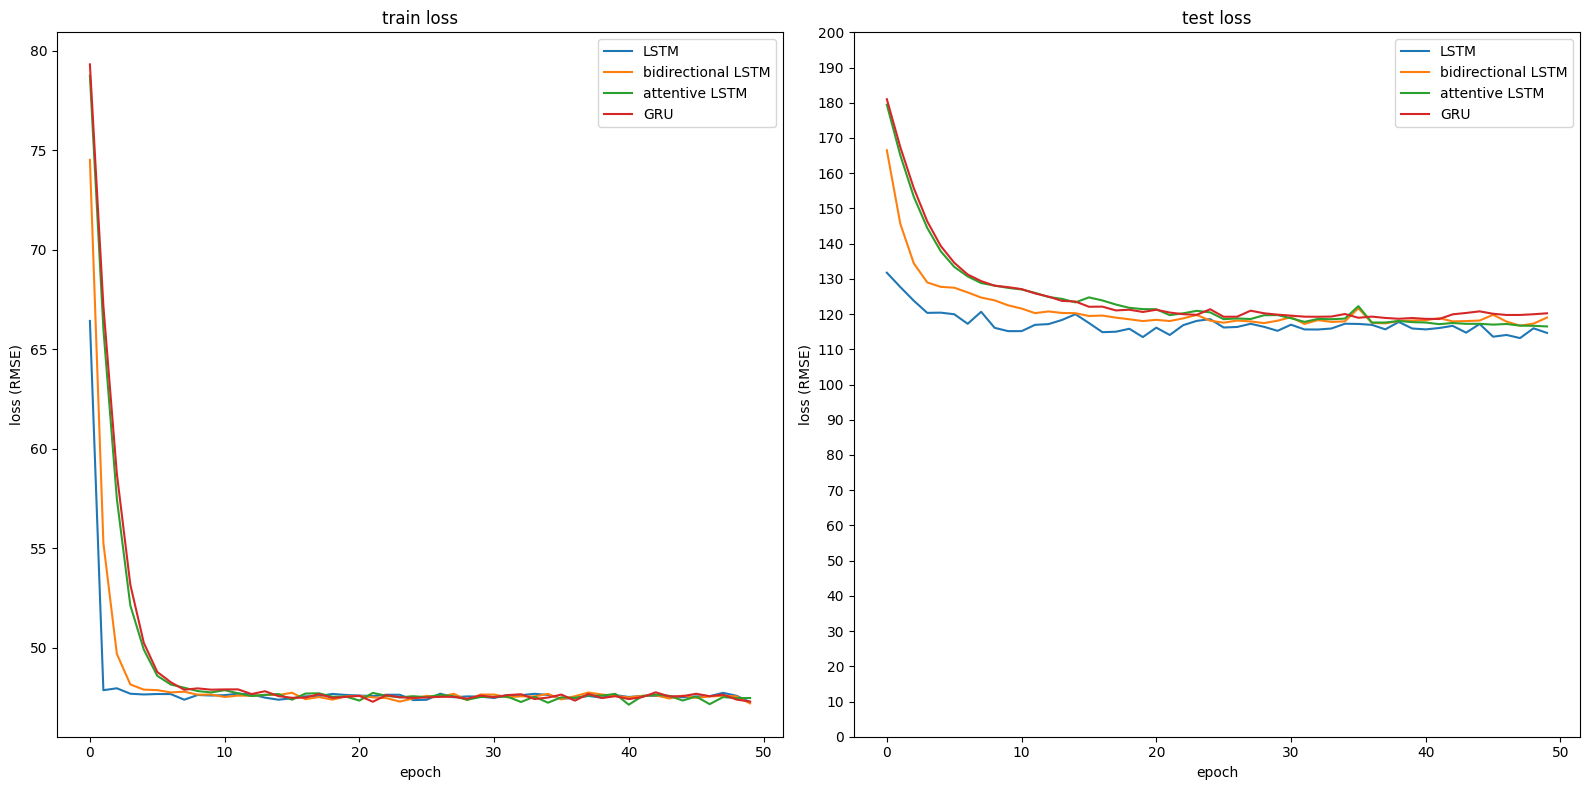

In [34]:
df_res1v3 = make_df_from_res(res1v3)
df_res2v3 = make_df_from_res(res2v3)
df_res3v3 = make_df_from_res(res3v3)
df_res4v3 = make_df_from_res(res4v3)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1v3["epoch"], df_res1v3["train_loss"], label="LSTM");
plt.plot(df_res2v3["epoch"], df_res2v3["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3v3["epoch"], df_res3v3["train_loss"], label="attentive LSTM");
plt.plot(df_res4v3["epoch"], df_res4v3["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1v3["epoch"], df_res1v3["test_loss"], label="LSTM");
plt.plot(df_res2v3["epoch"], df_res2v3["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3v3["epoch"], df_res3v3["test_loss"], label="attentive LSTM");
plt.plot(df_res4v3["epoch"], df_res4v3["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.yticks(np.arange(0, 210, 10));
plt.title("test loss");


plt.tight_layout();